# Magnetostatics: The Field of a Circular Coil

The electrostatic notebooks solved for a scalar potential. Magnetostatics needs a
vector potential $\vec{A}$, defined through $\vec{B} = \nabla \times \vec{A}$, and
the equation to solve is the curl–curl problem

$$\nabla \times \left(\nu\, \nabla \times \vec{A}\right) = \vec{J} .$$

In FIT this translates directly into

$$\mathbf{C}^\mathsf{T} \mathbf{M}_\nu \mathbf{C}\, \hat{a} = \hat{\hat{\jmath}},$$

where $\hat{a}$ is the vector potential integrated along the primal edges,
$\hat{\hat{\jmath}}$ the current through the dual facets, and $\mathbf{M}_\nu$ the
reluctivity matrix — the magnetic counterpart of $\mathbf{M}_\varepsilon$, holding
the dual edge length divided by the primal facet area.

Two properties of this system differ from the electrostatic case and shape
everything that follows.

**The null space is large.** Since $\mathbf{C}\mathbf{G} = 0$ holds identically,
every gradient field lies in it: $\vec{A}$ is determined only up to $\nabla\phi$.
Where the electrostatic problem had a one-dimensional null space that a single
pinned node removed, this one spans roughly $N_p$ of the $3N_p$ unknowns, and
eliminating it would mean constraining a spanning tree of the grid. An iterative
solver converges to one particular solution without needing that; a direct
factorisation does not.

**The gauge does not matter.** Taking the curl annihilates gradients, so every
solution in that null space yields the same $\vec{B}$. The quantity to compare
between runs is therefore $\mathbf{C}\hat{a}$, never $\hat{a}$ itself.

The cell below loads the package and defines three helpers: a boundary projection,
the analytical on-axis field of a current loop for later comparison, and a routine
for plotting field slices.

In [1]:
using Pkg
Pkg.activate(joinpath(@__DIR__, ".."); io = devnull)
Pkg.develop(path = joinpath(@__DIR__, "..", ".."); io = devnull)
using FITToolbox;
using Statistics
using LinearAlgebra
using CairoMakie
CairoMakie.activate!(type = "png", px_per_unit = 1)
using IterativeSolvers
using SparseArrays

function get_tangential_boundary(config::FITDomain)
    diag_vec = ones(Float64, 3*config.Np)
    # zero out the tangential entries; the rest pass through unchanged
    diag_vec[get_all_tangential_boundary_indices(config)] .= 0.0
    return spdiagm(0 => diag_vec)
end

# On-axis field of a circular loop of radius R carrying current I,
# at distance d from the loop centre.
B_axis_analytical(d, R, I) = FITToolbox.μ₀ * I * R^2 / (2 * (R^2 + d^2)^1.5)


# This function is just used to ease plotting
function plot_b_slice(domain, b̂̂, z_pos;
                      range = 1.0:99.0, units = "m", step = 5, title = nothing)

    B = [FITToolbox.interpolate(domain, PrimalFacet(), b̂̂,
                                x, y, Float64(z_pos); units = units)
         for x in range, y in range]
    Bmag = [hypot(b...) for b in B]

    # Arrows normalised to equal length, so direction stays readable where |B|
    # spans decades.
    sub = 1:step:length(range)
    u = [B[i,j][1] / (Bmag[i,j] + eps()) * 2 for i in sub, j in sub]
    v = [B[i,j][2] / (Bmag[i,j] + eps()) * 2 for i in sub, j in sub]

    fig, ax, hm = heatmap(range, range, log10.(Bmag); colormap = :viridis)
    Colorbar(fig[1,2], hm; label = "|B| log₁₀ (T)")

    arrows2d!(ax, range[sub], range[sub], u, v;
              tiplength = 8, tipwidth = 6, color = :white)

    ax.title  = something(title, "|B| at z = $z_pos $units")
    ax.xlabel = "x ($units)"
    ax.ylabel = "y ($units)"
    return fig
end

plot_b_slice (generic function with 1 method)

## Domain and coil

A $100 \times 100 \times 100\;\text{m}$ vacuum domain at $1\;\text{m}$ resolution,
with a circular coil of radius $10\;\text{m}$ centred in it. The coil is normal to
$u$, so it lies in the $v$–$w$ plane and the edges it occupies are $v$- and
$w$-directed.

`create_circular_loop_source` returns a vector of length $3N_p$ carrying $\pm 1$ on
the primal edges the loop crosses and zero elsewhere — a discrete current path
rather than a list of indices. Multiplying by the current gives the right-hand side
of the system directly.

The signs are what make it a *loop* rather than a set of unconnected edges: they
are chosen so the current circulates consistently, entering each cell where it
leaves the previous one. That closure is not cosmetic. A singular system is only
solvable when the right-hand side lies in the range of the matrix, which here means

$$\tilde{\mathbf{S}}\,\hat{\hat{\jmath}} = 0,$$

the discrete divergence of the current taken over the dual grid — current
continuity, with no charge accumulating anywhere. An open or inconsistent path
violates it, and no iterative solver will then converge to anything meaningful.
The function checks this itself and warns if the path it produced is not
divergence free.

In [2]:
MyDomain = create_domain([100,100,100],[1,1,1];units="m",σ=0,ε_r=1,μ_r=1); 

x_center = MyDomain.nodes_u[end] / 2
y_center = MyDomain.nodes_v[end] / 2
z_center = MyDomain.nodes_w[end] / 2

coil_current = 1 #A
coil_radius = 10.0 #m
wire = create_circular_loop_source(MyDomain,coil_radius,x_center,y_center,z_center,DirX();units="m");
J = coil_current .* wire;

## Magnetic boundary conditions

The magnetic wall, $\mathbf{n} \times \vec{H} = 0$, needs no treatment at all: it is
the natural boundary condition of the curl–curl operator, just as homogeneous Neumann
is for the Poisson operator in the electrostatic notebooks. The system is assembled
from the plain curl.

The reason is the truncated dual grid. For an edge lying in the boundary, Ampère's
law $\mathbf{C}^\mathsf{T}\hat{h} = \hat{\hat{\jmath}}$ sums the magnetic voltage
around its dual facet, which is cut in half by the wall. The three sides inside the
domain are dual edges and carry $\hat{h}$; the side lying on the wall has no dual
edge, so it contributes nothing. That is $H_t = 0$ exactly at the wall, and for a
linear material $\mathbf{n} \times \vec{B} = 0$: flux may only cross the boundary
perpendicularly.

A projection from the **left** does *not* impose this condition, even though it looks
like the natural counterpart of the electric wall below. Rows of $\mathbf{C}$ are
facets, and deleting a row does not constrain that facet's flux — it removes its
energy term, which is the same as setting $\nu = 0$ there. For the tangential facets
of the first cell layer this acts like an infinitely permeable lining and moves the
wall about half a cell into the domain. Because of the canonical indexing it does so
only on the three negative faces; on the positive faces the rows it deletes belong to
dead facets. Columns are different: they are unknowns, so deleting a column really
fixes $\hat{a} = 0$ there. That is how the electric wall further down is imposed.

The reluctivity matrix $\mathbf{M}_\nu$ is the magnetic constitutive relation,
$\hat{h} = \mathbf{M}_\nu \hat{\hat{b}}$, diagonal with each entry the dual edge
length divided by the primal facet area, scaled by $\nu = 1/\mu$. It is what makes
the natural condition exact: facets lying in a boundary plane carry their half dual
edge, and the dead facets beyond the last plane carry exactly zero, so no energy from
outside the domain enters. $\mathbf{M}_\nu$ is the same for both boundary conditions;
only $\mathbf{C}$ is rebuilt for the electric case.


In [3]:
# Magnetic walls (n × H = 0) are the natural condition of CᵀM_νC: facets in the
# boundary planes carry half dual edges, dead facets carry zero, nothing outside
# the domain enters. No projection is needed.
C   = get_curl(MyDomain, Primal())
M_ν = get_reluctivity(MyDomain)

dead_facets = get_custom_boundary_indices(MyDomain,
    [(DirX(), Positive()), (DirY(), Positive()), (DirZ(), Positive())], TangentialComponent())
all(iszero, diag(M_ν)[dead_facets]) || error("dead facets carry reluctivity")
println("dead facets carry zero reluctivity: the unprojected operator is the natural one")

A = C' * M_ν * C

dead facets carry zero reluctivity: the unprojected operator is the natural one


3090903×3090903 SparseMatrixCSC{Float64, Int64} with 40058309 stored entries:
⎡⠻⣦⡀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠙⢦⡀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠘⢦⡀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⎤
⎢⠀⠈⠻⣦⡀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠙⢦⡀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠙⢦⡀⠀⠀⠀⠀⠀⠀⠀⠀⠀⎥
⎢⠀⠀⠀⠈⠻⣦⡀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠙⢦⡀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠙⢦⡀⠀⠀⠀⠀⠀⠀⠀⎥
⎢⠀⠀⠀⠀⠀⠈⠻⣦⡀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠙⢦⡀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠙⢦⡀⠀⠀⠀⠀⠀⎥
⎢⠀⠀⠀⠀⠀⠀⠀⠈⠻⣦⡀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠙⢦⡀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠙⢦⡀⠀⠀⠀⎥
⎢⠀⠀⠀⠀⠀⠀⠀⠀⠀⠈⠻⣦⡀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠙⢦⡀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠙⢦⡀⠀⎥
⎢⣄⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠈⠻⣦⡀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠙⢦⡀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠙⠦⎥
⎢⠈⠳⣄⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠈⠻⣦⡀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠙⢦⡀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⎥
⎢⠀⠀⠈⠳⣄⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠈⠻⣦⡀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠙⢦⡀⠀⠀⠀⠀⠀⠀⠀⠀⎥
⎢⠀⠀⠀⠀⠈⠳⣄⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠈⠻⣦⡀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠙⢦⡀⠀⠀⠀⠀⠀⠀⎥
⎢⠀⠀⠀⠀⠀⠀⠈⠳⣄⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠈⠻⣦⡀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠙⢦⡀⠀⠀⠀⠀⎥
⎢⠀⠀⠀⠀⠀⠀⠀⠀⠈⠳⣄⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠈⠻⣦⡀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠙⢦⡀⠀⠀⎥
⎢⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠈⠳⣄⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠈⠻⣦⡀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠙⢦⡀⎥
⎢⠲⣄⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠈⠳⣄⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠈⠻⣦⡀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠙⎥
⎢⠀⠈⠳⣄⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠈⠳⣄⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠈⠻⣦⡀⠀⠀⠀⠀⠀⠀⠀⠀⠀⎥
⎢⠀⠀⠀⠈⠳⣄⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠈⠳⣄⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠈⠻⣦⡀⠀⠀⠀⠀⠀⠀⠀⎥
⎢⠀⠀⠀⠀⠀⠈⠳⣄⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠈⠳⣄⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠈⠻⣦⡀⠀⠀⠀⠀⠀⎥
⎢⠀⠀⠀⠀⠀⠀⠀⠈⠳⣄⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠈⠳⣄⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠈⠻⣦⡀⠀⠀⠀⎥
⎢⠀⠀⠀⠀⠀⠀⠀⠀⠀⠈⠳⣄⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠈⠳⣄⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠈⠻⣦⡀⠀⎥
⎣⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠈⠳⡄⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠈⠳⣄⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠈⠻⣦⎦

## Solving the curl–curl system

Conjugate gradients suits this system: $\mathbf{A}$ is real, symmetric and
positive semi-definite, and CG converges on a singular system provided the
right-hand side is consistent — which the divergence-free current guarantees. It
needs only three vectors and one matrix–vector product per iteration, where a
general non-symmetric method such as IDR(s) carries a shadow space and does more
work per step.

A direct solver is not available. `cholesky` requires positive definiteness and
throws on this matrix, because the gauge freedom leaves it merely semi-definite.
Removing that freedom — by tree–cotree gauging, or by adding a grad–div
regularisation — would make a factorisation possible, but neither is necessary as
long as an iterative method is used.

The residual printed below is computed directly from the result rather than read
from the iteration history. On a singular system the recurrence residual can
stagnate in the null direction while the true one is fine, so the direct
calculation is the one to trust.

The slice cuts through the centre of the domain, in a plane containing the coil
axis. The coil crosses this plane at two points, visible as the two bright
regions, and the field circulates around each — the poloidal pattern of a current
loop seen edge-on.

At the walls the arrows meet the boundary **perpendicularly**, which is the
condition imposed: with $\mathbf{n} \times \vec{B} = 0$ no tangential component
survives, so whatever flux reaches the boundary must pass straight through it.
The electric case below shows the exact opposite.

Converged:     true
Iterations:    397
True residual: 9.875485041500633e-11


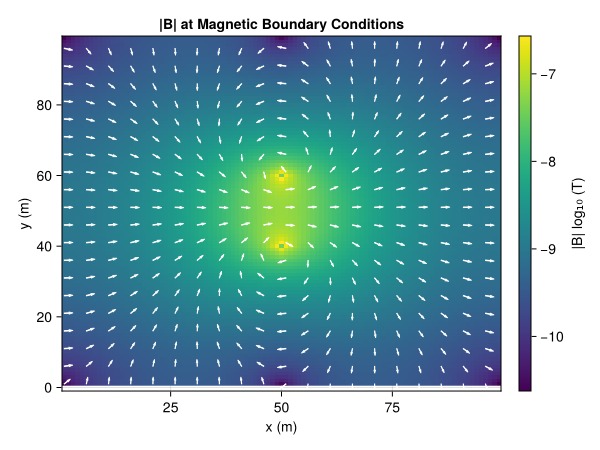

In [4]:
â, history =  cg(A, J; reltol=1e-10, maxiter=1000, log=true)
println("Converged:     ", history.isconverged)
println("Iterations:    ", history.iters)
println("True residual: ", norm(A * â - J) / norm(J))

# Calculate magnetic flux from line integrated vector potential
b̂̂_Magnetic = C * â

plot_b_slice(MyDomain, b̂̂_Magnetic, z_center; title = "|B| at Magnetic Boundary Conditions")

## Electric boundary conditions

The same projection matrix, now applied from the **right**. Columns of
$\mathbf{C}$ are indexed by edges, so this constrains the vector potential rather
than the flux: the tangential components of $\hat{a}$ are set to zero on all six
faces.

That is enough to fix the flux as well. By Stokes' theorem the normal component
of $\vec{B}$ through a surface is determined entirely by the circulation of
$\vec{A}$ around its edge, so killing the tangential $\vec{A}$ on a face forces
$\mathbf{n} \cdot \vec{B} = 0$ there. No flux crosses the boundary at all, and the
field is obliged to run parallel to it — the condition a perfect electric
conductor imposes.

This is the exact complement of the previous case. There, flux could only leave
perpendicularly; here it cannot leave at all. In the slice below the arrows lie
**along** the walls rather than meeting them head-on, which is the visible
signature of the change.

Only $\mathbf{C}$ is rebuilt: $\mathbf{M}_\nu$ is a material property and knows
nothing about the boundary. The system remains symmetric positive semi-definite,
and CG applies for the same reasons as before.

Neither condition is what an isolated coil in free space experiences, so both
distort the field near the walls. The comparison in the next cell shows by how much, and whether each one over- or underestimates the field.

Converged:     true
Iterations:    346
True residual: 9.887439534570007e-11


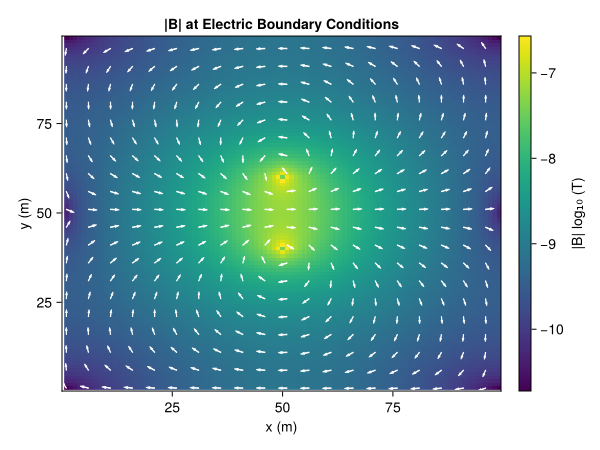

In [5]:
# Now generate Curl that sets the tangential vector potential to zero to get electric boundary conditions
C = get_curl(MyDomain,Primal())*get_tangential_boundary(MyDomain);

A = C' * M_ν * C 

â, history =  cg(A, J; reltol=1e-10, maxiter=1000, log=true)
println("Converged:     ", history.isconverged)
println("Iterations:    ", history.iters)
println("True residual: ", norm(A * â - J) / norm(J))

b̂̂_Electric = C*â
plot_b_slice(MyDomain, b̂̂_Electric, z_center; title = "|B| at Electric Boundary Conditions")

## Comparison along the coil axis

On the axis of a circular loop the field is known in closed form,

$$B(d) = \frac{\mu_0 I R^2}{2\left(R^2 + d^2\right)^{3/2}},$$

with $d$ measured from the centre of the loop. Sampling both numerical solutions
along that line gives a direct check of the discretisation and shows what each
boundary condition costs.

Near the coil all three curves agree: the walls are far away and the grid resolves
the field well. Further out they separate, and the two conditions err in opposite
directions.

**Magnetic conditions overestimate.** With $\mathbf{n} \times \vec{B} = 0$ the
boundary lets flux out only perpendicularly, which is a poor match for a dipole
field that would naturally curl back. Flux that should return through the region
is instead pushed out through the walls, and the axial field is left stronger than
in free space.

**Electric conditions underestimate.** With $\mathbf{n} \cdot \vec{B} = 0$ no flux
crosses the boundary at all. The return path is squeezed into the domain, the
field lines are compressed against the walls, and the axial field falls below the
free-space value.

The true solution lies between them, which is useful in itself: running both
brackets the answer, and the gap between the curves measures how much the finite
domain is distorting the result. Both deviations shrink as the walls move away —
they are statements about the domain size rather than about the method.

For open-boundary treatments that reduce this error at modest cost, see the graded
mesh and Robin conditions in the electrostatic notebooks. Both carry over here,
with one caveat: a current loop is a magnetic *dipole*, so its field decays as
$1/r^3$ rather than the $1/r$ of a point charge. Truncation error is correspondingly
smaller to begin with, and a Robin condition would need the coefficient matched to
that faster decay.

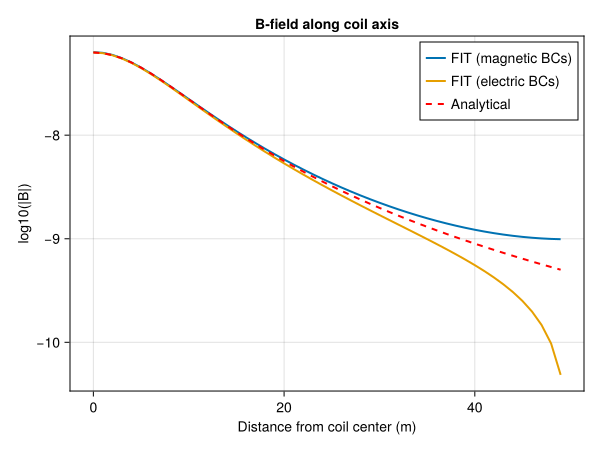

In [6]:
xs = 50.0:99.0
d  = xs .- x_center                    # distance from the coil centre along the axis

Bmag = [hypot(FITToolbox.interpolate(MyDomain, PrimalFacet(), b̂̂_Magnetic,
                                     x, Float64(y_center), Float64(z_center); units="m")...)
        for x in xs]

Belec = [hypot(FITToolbox.interpolate(MyDomain, PrimalFacet(), b̂̂_Electric,
                            x, Float64(y_center), Float64(z_center); units="m")...)
for x in xs]

fig, ax = lines(d, log10.(Bmag); label = "FIT (magnetic BCs)", linewidth = 2)
lines!(d, log10.(Belec); label = "FIT (electric BCs)", linewidth = 2)
lines!(ax, d, log10.(B_axis_analytical.(d, coil_radius, coil_current));
       label = "Analytical", linewidth = 2, linestyle = :dash, color = :red)

ax.xlabel = "Distance from coil center (m)"
ax.ylabel = "log10(|B|)"
ax.title  = "B-field along coil axis"
axislegend(ax)
fig